# Segmentation of Breast Cancer with U-Net

Giorgia Cappellato 5410259

Andrea Frattesi 5411003


## Introduction

In this section, we focus on the segmentation task, which goal is to identify and localize cancerous tissue at pixel level within breast ultrasound images.

Segmentation is particularly important in medical imaging, as it provides spatial information about the tumor, allowing clinicians to better understand its size, shape, and location.
Only benign and malignant images are considered for this task, since normal images do not have associated ground-truth masks.
As a result, the segmentation dataset contains 697 images.

## Libraries

In [ ]:
from importlib import reload
from sklearn.model_selection import train_test_split
import os
import glob
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from datetime import datetime
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import cv2
import re
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import torch.nn.functional as F

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset Creation and Transformation

Define transformations to ensure fixed image size and data augumentation.

In [ ]:
# Define Transformation
custom_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(degrees=30),  # Random rotation within +-30 degrees
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),  # Random translation within 10% of the image dimensions
        shear=(-15, 15)  # Random shear (tilt) +-15 degrees
    ),
    transforms.RandomHorizontalFlip(),  # Random horizontal flip
    transforms.RandomVerticalFlip(),    # Random vertical flip
    transforms.Resize(
        (64,64), # height and width
        interpolation=InterpolationMode.NEAREST,
        antialias=False
    )
])

resize_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(
        (64, 64),
        interpolation=InterpolationMode.NEAREST,
        antialias=False
    )
])

A custom *SegmentationDataset* is created to ensure that each ultrasound image is correctly paired with its corresponding mask and that both undergo consistent preprocessing. This guarantees reliable data loading and prevents errors during training and evaluation.

In [ ]:
class SegmentationDataset(Dataset):

    def __init__(self, pth_data, transform = None, train = True, test_size = .2, seed = 42):

        # inherit paret methods
        super().__init__()

        # save images and corresponding masks
        self.pth_data = pth_data
        self.img_mask_dict = None
        self.transform = transform

        # initilize the img_mask_dict
        self.initialize_img_mask_dict()

        # train / test
        items = list(self.img_mask_dict.items())

        # Split the list into train and test sets
        train_items, test_items = train_test_split(items, test_size=test_size, random_state=seed)

        # Convert the train and test sets back into dictionaries
        train_dict = dict(train_items)
        test_dict = dict(test_items)
        if train:
            self.img_mask_dict = train_dict
        else:
            self.img_mask_dict = test_dict


    def initialize_img_mask_dict(self):

        def get_type_and_id(pth_png):
            type = ''
            id = None

            png_name = os.path.basename(pth_png)

            if 'malignant' in png_name:
                type = 'malignant'
            if 'benign' in png_name:
                type = 'benign'
            if 'normal' in png_name:
                type = 'normal'

            id = re.search(r'\((\d+)\)', png_name).group(1)

            return type, id

        def get_masks(pth_image, pth_masks):

            img_type, img_id = get_type_and_id(pth_image)

            masks = []

            for pth_mask in pth_masks:
                mask_type, mask_id = get_type_and_id(pth_mask)
                if mask_type == img_type and mask_id == img_id:
                    masks.append(pth_mask)
            return masks

        # paths of all pngs
        pth_pngs = glob.glob(os.path.join(self.pth_data,'**','*.png'))

        # path of images
        # pth_images = [pth for pth in pth_pngs if 'mask' not in pth]
        pth_images = [pth for pth in pth_pngs if 'mask' not in pth and 'normal' not in pth]

        # path of masks
        pth_masks = [pth for pth in pth_pngs if 'mask' in pth]

        # image masks paths list dict
        self.img_mask_dict = {pth_image : get_masks(pth_image, pth_masks) for pth_image in pth_images}

    def __len__(self):
        return len(self.img_mask_dict)

    def __getitem__(self, index):

        def merge_masks(masks):
            sum_maks = None
            for idx,mask in enumerate(masks):
                if idx == 0:
                    sum_maks = cv2.imread(mask,cv2.IMREAD_GRAYSCALE)
                else:
                    sum_maks += cv2.imread(mask,cv2.IMREAD_GRAYSCALE)
            return sum_maks / 255

        # read img and masks paths
        pth_img, pth_masks = list(self.img_mask_dict.items())[index]

        # convert to numpy the image
        image = cv2.imread(pth_img,cv2.IMREAD_GRAYSCALE)

        # convert to numpy the mask
        mask = merge_masks(pth_masks)

        # apply transformations if needed
        if self.transform is not None:
            seed = random.randint(0, 2**32)
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.transform(image)
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.transform(mask)

        image = image.float()
        mask = mask.float()

        return image, mask

In [ ]:
# Create the Train and Test Datasets

train_dataset = SegmentationDataset('/content/drive/MyDrive/Breast Cancer Detection/dataset', transform = custom_transform, train = True, test_size = .2, seed = 42)
test_dataset = SegmentationDataset('/content/drive/MyDrive/Breast Cancer Detection/dataset', transform = resize_transform, train = False, test_size = .2, seed = 42) # resize only

In [ ]:
print(f'Train Set Size: {len(train_dataset)}')
print(f'Test Set Size: {len(test_dataset)}')

Train Set Size: 517
Test Set Size: 130


In [ ]:
print(f'Image, Mask shapes in Train: {train_dataset[43][0].shape}, {train_dataset[43][1].shape}')
print(f'Image, Mask shapes in Test: {test_dataset[43][0].shape}, {test_dataset[43][1].shape}')

Image, Mask shapes in Train: torch.Size([1, 64, 64]), torch.Size([1, 64, 64])
Image, Mask shapes in Test: torch.Size([1, 64, 64]), torch.Size([1, 64, 64])


The *plot_example* function is used to visually inspect samples from the segmentation dataset. For a given index, it displays:
- The original ultrasound image
- The corresponding ground-truth segmentation mask

This visualization serves two main purposes:
- Data validation: it allows us to verify that images and masks are correctly aligned and loaded by the *SegmentationDataset*.
- Qualitative understanding: it helps understand the shape, size, and variability of tumor regions within the dataset.
Visual inspection at this stage is crucial to detect potential issues before training the model.

The *plot_prediction* function is used to evaluate the segmentation model qualitatively by comparing predictions with ground-truth masks.
For a selected test sample, the function displays:
- The input ultrasound image
- The ground-truth segmentation mask
- The predicted mask generated by the model

The predicted mask is obtained by applying a sigmoid activation to the model output and thresholding the resulting probability map to produce a binary segmentation.
This visualization allows us to:
- Assess how accurately the model localizes tumor regions
- Compare predicted shapes with the true annotations
- Identify typical errors such as under-segmentation or over-segmentation

Together with quantitative metrics, these plots provide an intuitive understanding of the model’s segmentation performance.

In [ ]:
def plot_example(example, image_title='Image', mask_title='Mask'):
    image = example[0].squeeze()
    mask = example[1].squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(image_title)
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(mask_title)
    axes[1].axis('off')

    plt.show()

def plot_prediction(example, pred_mask,image_title='Image', mask_title='Mask',pred_title = 'predicted'):

    image = example[0].squeeze()
    mask = example[1].squeeze()
    prediction = pred_mask.squeeze()

    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(image_title)
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(mask_title)
    axes[1].axis('off')

    axes[2].imshow(prediction, cmap='gray')
    axes[2].set_title(pred_title)
    axes[2].axis('off')

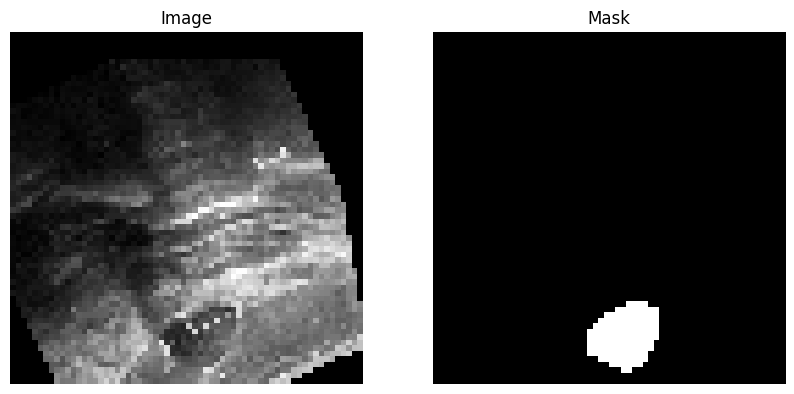

In [ ]:
plot_example(train_dataset[234])

In [ ]:
# Create training and test DataLoader

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)
test_loader = DataLoader(test_dataset,  shuffle=False, batch_size=32)
print(f'Batch Size : {train_loader.batch_size}')
num_train_batches = len(train_dataset) // train_loader.batch_size
num_test_batches = len(test_dataset) // test_loader.batch_size
print(f'Number Batches in Train: {num_train_batches}')
print(f'Number Batches in Test: {num_test_batches}')

Batch Size : 32
Number Batches in Train: 16
Number Batches in Test: 4


In [ ]:
# Checking which device we are using

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available() :
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using: {device}')

Using: cuda


## Model architecture: U-Net

U-Net architecture consists of two main components:
- Encoder (contracting path): extracts hierarchical features from the input image through successive convolutional and downsampling layers.
- Decoder (expanding path): progressively upsamples feature maps to reconstruct the segmentation mask.

A key feature of U-Net is the presence of skip connections, which directly connect encoder layers to their corresponding decoder layers. This helps preserve spatial information lost during downsampling and improves segmentation accuracy.

In [ ]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels, mid_channels = None):
        super().__init__()

        # if no number of mid channel is specified, use out channels
        if not mid_channels:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3,padding='same'),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3,padding='same'),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
            )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = (DoubleConv(n_channels, 64))
        self.down1 = (Down(64, 128))
        self.down2 = (Down(128, 256))
        self.down3 = (Down(256, 512))
        factor = 2 if bilinear else 1
        self.down4 = (Down(512, 1024 // factor))
        self.up1 = (Up(1024, 512 // factor, bilinear))
        self.up2 = (Up(512, 256 // factor, bilinear))
        self.up3 = (Up(256, 128 // factor, bilinear))
        self.up4 = (Up(128, 64, bilinear))
        self.outc = (OutConv(64, n_classes))

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

In [ ]:
model = UNet(1,1).to(device)

In [ ]:
num_param = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of Learnable Parameters: {num_param}')

Number of Learnable Parameters: 31042369


We test the model on the first image to check the shape of the output.

In [ ]:
# Random tensor
input_tensor = torch.randn(1, 1, 64, 64).to(device)

model.eval()
with torch.no_grad():
    output = model(input_tensor)
print(output.shape)

torch.Size([1, 1, 64, 64])


## Training Setup

**Input and Preprocessing**
- Input images are resized to 64×64 pixels
- Images are converted to grayscale
- Corresponding masks are used as ground truth for supervision

**Loss Function**: The model is trained using Binary Cross-Entropy with Logits Loss (*BCEWithLogitsLoss*), which combines:
- A sigmoid activation
- Binary Cross-Entropy loss

This choice is suitable for binary segmentation, where each pixel is classified as either tumor or background.

**Optimizer and Learning Rate Schedule**
- Optimizer: Stochastic Gradient Descent (SGD) with Nesterov momentum
- Momentum: 0.9
- Weight Decay: 1e-5
- Learning Rate Schedule: Cosine Annealing
- Initial Learning Rate: 0.1
- Final Learning Rate: 1e-5

The cosine annealing schedule allows the learning rate to gradually decrease, improving convergence stability during later training stages.

In [ ]:
# Loss fn
loss_fn = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True, weight_decay = 0.00001)

# Scheduler
scheduler = CosineAnnealingLR(optimizer, T_max= 50, eta_min=0.00001)

## Checkpoints

During training, **model checkpointing** is used to save the network’s parameters at specific stages.
This allows us to preserve the best-performing model, resume training if interrupted, and avoid losing progress in long training sessions.
By storing checkpoints, we ensure reproducibility, stability, and reliable evaluation of the segmentation model.

In [ ]:
# Create checkpoint directory
os.makedirs('/content/drive/MyDrive/Breast Cancer Detection/checkpoint', exist_ok=True)

# Save checkpoint
def save_checkpoint(epoch, model, optimizer, scheduler, train_loss_epoch_history, test_loss_epoch_history):
    # generate name using current time
    filepath = os.path.join('/content/drive/MyDrive/Breast Cancer Detection/checkpoint', datetime.now().strftime('%Y-%m-%d_%H:%M:%S') + '_checkpoint.pt')
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss_epoch_history': train_loss_epoch_history,
        'test_loss_epoch_history': test_loss_epoch_history
    }
    torch.save(checkpoint, filepath)
    print(f'Checkpoint saved at epoch {epoch+1}')

# Load checkpoint
def load_checkpoint(filepath, model, optimizer, scheduler):
    checkpoint = torch.load(filepath)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    epoch = checkpoint['epoch']+1
    train_loss_epoch_history = checkpoint['train_loss_epoch_history']
    test_loss_epoch_history = checkpoint['test_loss_epoch_history']
    print(f'Checkpoint loaded from epoch {epoch}\n')
    return epoch, train_loss_epoch_history, test_loss_epoch_history

## Training and Evaluation Loop

In [ ]:
print(f'Number of Epochs: {50}')

Number of Epochs: 50


In [ ]:
# Define the cosine learning rate scheduler
train_loss_epoch_history = []
test_loss_epoch_history = []

# Checkpoint name
checkpoint_name = 'checkpoint.pth'  # specify the checkpoint file name
start_epoch = 0

# Load checkpoint if it exists
load_checkpoint = False
if load_checkpoint:
    checkpoint_path = os.path.join('/content/drive/MyDrive/Breast Cancer Detection/checkpoint', checkpoint_name)
    start_epoch, train_loss_epoch_history, test_loss_epoch_history = load_checkpoint(checkpoint_path, model, optimizer, scheduler)
    print(start_epoch, train_loss_epoch_history,test_loss_epoch_history)

# Training loop
for epoch in range(start_epoch, 50):
    # Print epoch start
    print(f'Starting epoch: {epoch+1}\n-----------\n')
    print(f'learning rate: {scheduler.get_last_lr()}\n')

    # Set the model to training mode
    model.train()

    # Current epoch loss
    running_loss = 0.0
    total_samples = 0

    for idx, (inputs, labels) in enumerate(train_loader):
        # Send to device
        inputs, labels = inputs.to(device), labels.to(device)
        batch_size = inputs.size(0)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate the loss
        loss = loss_fn(outputs, labels)

        # Backward pass
        loss.backward()

        # Optimize
        optimizer.step()

        # Retrieve batch loss
        batch_loss = loss.item()

        # Add it to running loss
        running_loss += batch_loss * batch_size
        total_samples += batch_size

        # Print batch loss every 10 batches
        if idx % 10 == 0:
            print(f'batch: {idx}/{len(train_loader)}\tbatch loss: {batch_loss}')

    # Calculate average training loss for the epoch
    train_loss = running_loss / total_samples  # Divide by the number of samples
    train_loss_epoch_history.append(train_loss)
    print(f'End of epoch {epoch+1}/{50}\nTraining Loss: {train_loss}\n')

    # Step the scheduler
    scheduler.step()

    # Validation loop
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = inputs.size(0)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

    # Calculate average validation loss for the epoch
    val_loss = running_loss / total_samples  # Divide by the number of samples
    test_loss_epoch_history.append(val_loss)
    print(f'Validation Loss: {val_loss}\n------------\n')

    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        save_checkpoint(epoch, model, optimizer, scheduler, train_loss_epoch_history, test_loss_epoch_history)


Starting epoch: 1
-----------

learning rate: [0.1]

batch: 0/17	batch loss: 0.705656111240387
batch: 10/17	batch loss: 0.3082602918148041
End of epoch 1/50
Training Loss: 0.34901111364018755

Validation Loss: 0.3666606733432183
------------

Starting epoch: 2
-----------

learning rate: [0.09990134628777145]

batch: 0/17	batch loss: 0.23947422206401825
batch: 10/17	batch loss: 0.2018025517463684
End of epoch 2/50
Training Loss: 0.2407774091112775

Validation Loss: 0.3113622605800629
------------

Starting epoch: 3
-----------

learning rate: [0.09960577449221733]

batch: 0/17	batch loss: 0.21756047010421753
batch: 10/17	batch loss: 0.21840979158878326
End of epoch 3/50
Training Loss: 0.20036292727496222

Validation Loss: 0.6910684402172382
------------

Starting epoch: 4
-----------

learning rate: [0.0991144511001808]

batch: 0/17	batch loss: 0.20797297358512878
batch: 10/17	batch loss: 0.16316749155521393
End of epoch 4/50
Training Loss: 0.18100467866117304

Validation Loss: 0.34331

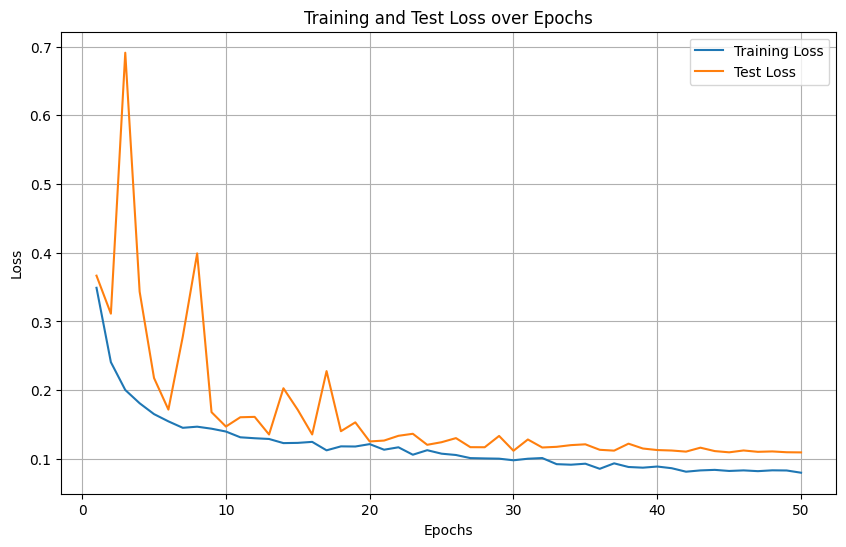

In [ ]:
epochs = range(1, len(train_loss_epoch_history) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss_epoch_history, label='Training Loss')
plt.plot(epochs, test_loss_epoch_history, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)

save_dir = '/content/drive/MyDrive/Breast Cancer Detection/figures'
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'training_test_loss_over_epochs_unet_with_att.png'))
plt.show()



During training, both training and validation losses are monitored.
From the loss curves, we observe that:
- An initial exploratory phase occurs at higher learning rates
- After approximately 20 epochs, training and validation losses start decreasing together
- After 40 epochs, the model reaches a stable regime with low and consistent errors

This behavior indicates good convergence and no significant overfitting.

# Test Results

## Training Set

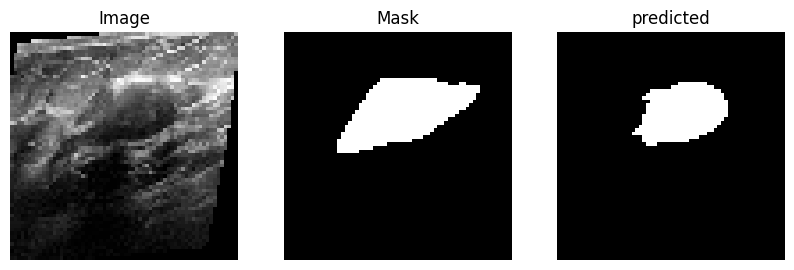

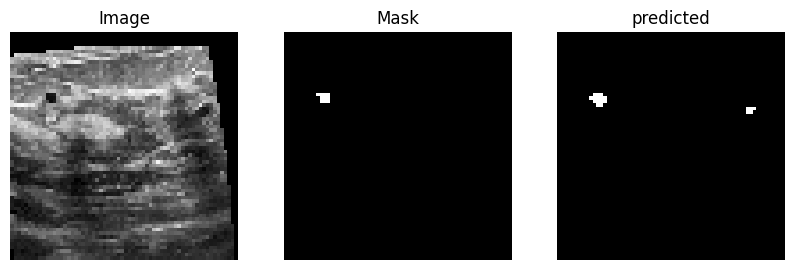

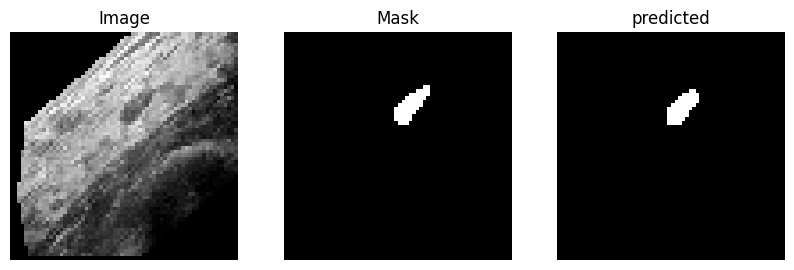

In [ ]:
def plot_prediction(example, pred_mask,image_title='Image', mask_title='Mask',pred_title = 'predicted'):

    image = example[0].squeeze()
    mask = example[1].squeeze()
    prediction = pred_mask.squeeze()

    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(image_title)
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(mask_title)
    axes[1].axis('off')

    axes[2].imshow(prediction, cmap='gray')
    axes[2].set_title(pred_title)
    axes[2].axis('off')

model.eval()
for idx in range(0, 3):
    with torch.no_grad():
        # Prepare input and label
        example = train_dataset[idx]
        input, label = example
        input = input.unsqueeze(0)
        input = input.to(device)
        label = label.to(device)

        # Get logits from the model
        logits = model(input)

        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(logits)

        # Convert probabilities to binary predictions (0 or 1)
        pred_mask = (probs > 0.5).cpu().numpy().astype(int)

        # Plot the prediction
        plot_prediction(example, pred_mask)

Find the best threshold for prediction using IoU.

In [ ]:
def average_iou(threshold):
    print('Using Threshold:', threshold)
    def IoU(img1,img2):
        img1 = img1.cpu().numpy()
        #img2 = img2.cpu().numpy()

        # Calculate intersection and union using bitwise operations
        inter = np.logical_and(img1, img2).sum()
        union = np.logical_or(img1, img2).sum()

        # Calculate IoU
        iou_value = inter / union if union != 0 else 0

        return iou_value

    total_iou = 0

    model.eval()
    for idx in range(len(train_dataset)):
        with torch.no_grad():
            # Prepare input and label
            example = train_dataset[idx]
            input, label = example
            input = input.unsqueeze(0)
            input = input.to(device)
            label = label.to(device)

            # Get logits from the model
            logits = model(input)

            # Apply sigmoid to get probabilities
            probs = torch.sigmoid(logits)

            # Convert probabilities to binary predictions (0 or 1)
            pred_mask = (probs >= threshold ).cpu().numpy().astype(int)

            iou = IoU(label, pred_mask)

            total_iou += iou

    return total_iou / len(train_dataset)

In [ ]:
thresholds = [.1,.2,.3,.4,.5,.6,.7,.8,.9]
iou_vs_threshold = [average_iou(thr) for thr in thresholds]

Using Threshold: 0.1
Using Threshold: 0.2
Using Threshold: 0.3
Using Threshold: 0.4
Using Threshold: 0.5
Using Threshold: 0.6
Using Threshold: 0.7
Using Threshold: 0.8
Using Threshold: 0.9


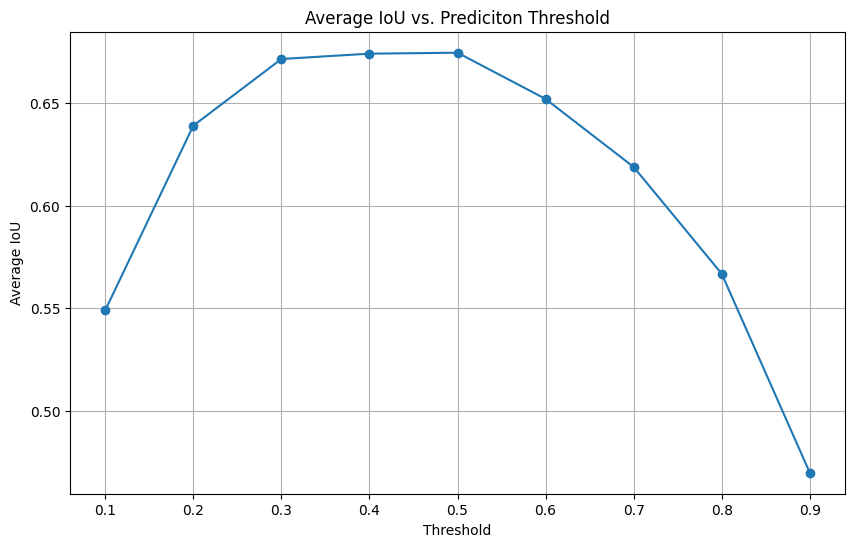

In [ ]:
# Plotting the IoU vs Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, iou_vs_threshold, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Average IoU')
plt.title('Average IoU vs. Prediciton Threshold')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Breast Cancer Detection/figures' +'/iou_thr_plot_train_2.png')
plt.show()

The model outputs, for each pixel, a value in the range (0, 1), representing the probability that the pixel belongs to a cancerous region.
To convert probability maps into binary masks, a threshold must be selected.

We determined the optimal threshold by computing the average Intersection over Union (IoU) on the training set, and evaluating IoU values across different threshold levels.
The best performance was achieved with a threshold of 0.5, which was therefore selected for inference.

## Test Set

In [ ]:
best_model = '/content/drive/MyDrive/Breast Cancer Detection/models_mask' + '/2025-12-11_19-52-06_model.pth'
segmentation_model = torch.load(best_model, weights_only=False).to(device)

<Figure size 640x480 with 0 Axes>

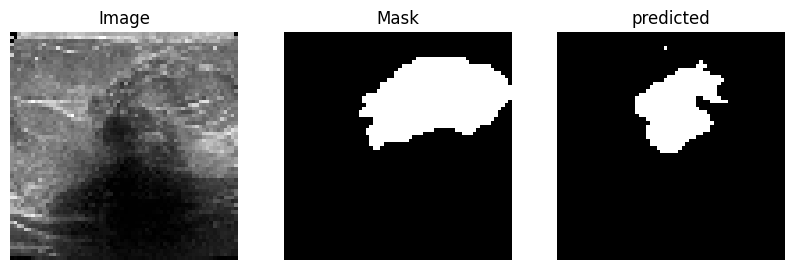

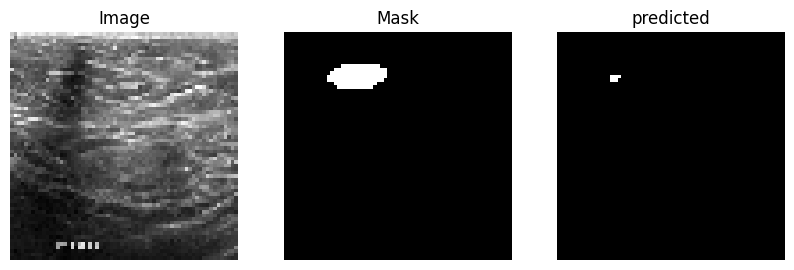

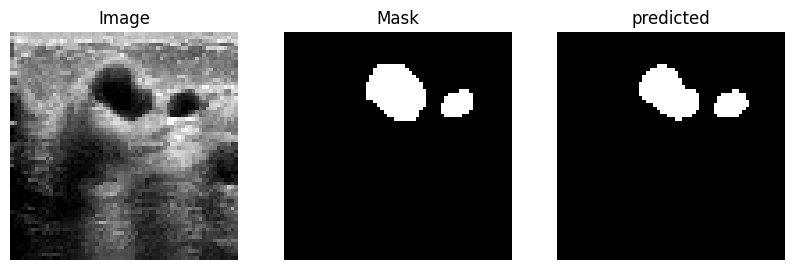

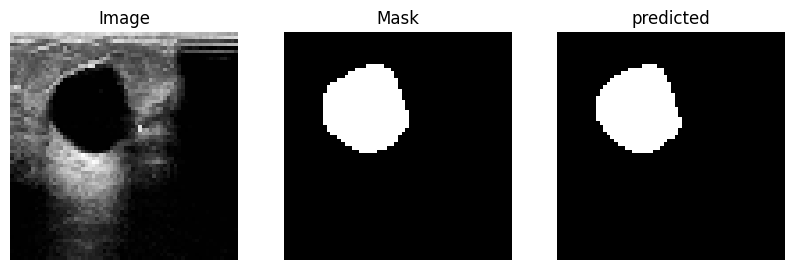

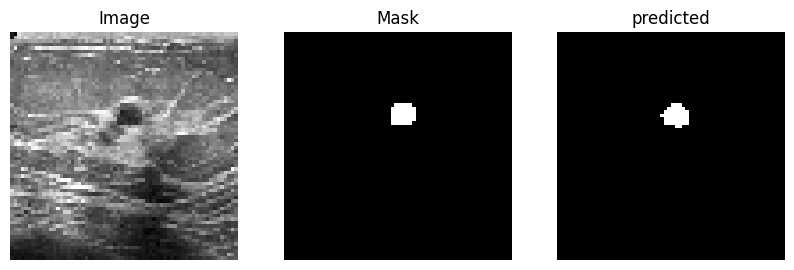

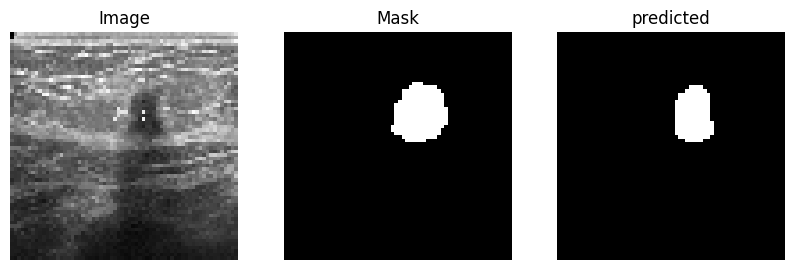

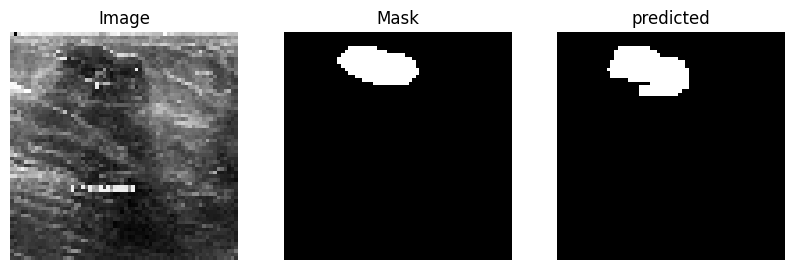

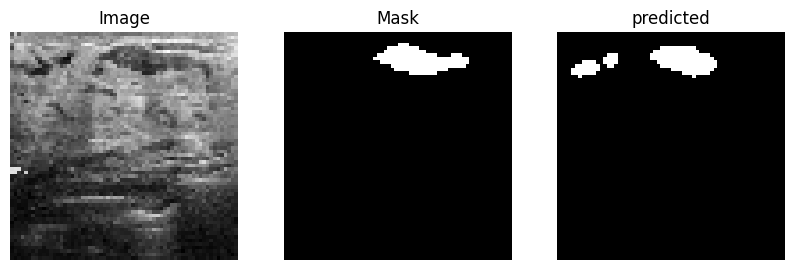

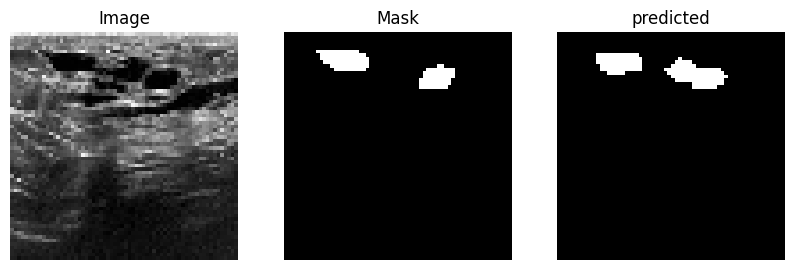

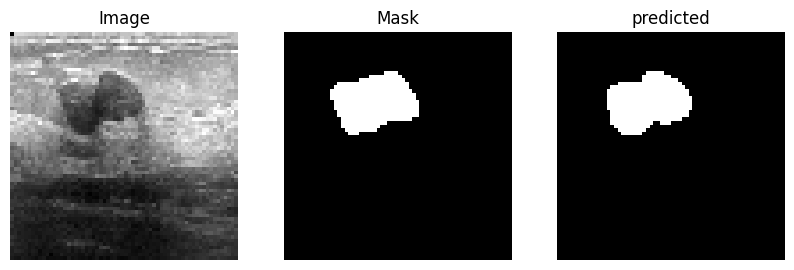

In [ ]:
model.eval()
for idx in range(0, 10):
    with torch.no_grad():
        # Prepare input and label
        example = test_dataset[idx]
        input, label = example
        input = input.unsqueeze(0)
        input = input.to(device)
        label = label.to(device)

        # Get logits from the model
        logits = model(input)

        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(logits)

        # Convert probabilities to binary predictions (0 or 1)
        pred_mask = (probs >= 0.5).cpu().numpy().astype(int)

        # Plot the prediction
        plt.savefig('/content/drive/MyDrive/Breast Cancer Detection/figures'+'/test_with_pred_'+str(idx)+'_.png')
        plot_prediction(example, pred_mask)

Qualitative results show that:
- Tumor regions are accurately localized.
- Predicted masks preserve the shape and extent of the lesions.
- The model generalizes well despite the relatively small dataset size.

These results confirm the effectiveness of the U-Net architecture for breast cancer segmentation in ultrasound images.

In [ ]:
# Save the model

model_pth_name = os.path.join('/content/drive/MyDrive/Breast Cancer Detection/models_mask', datetime.now().strftime('%Y-%m-%d_%H:%M:%S') + '_model.pth')
torch.save(model, model_pth_name)

## References

https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset

https://www.sciencedirect.com/science/article/pii/S2352340919312181?via%3Dihub#tbl1